# Time series exploration 

## Important remark : overall_dfs and 3D_alignment are 2 dataframes, one takes all features into account independently, whereas the other one treats  

In [1]:
import pandas as pd
import os
import pickle
import numpy as np
from scipy.interpolate import interp1d
import tqdm
from fastdtw import fastdtw

### First approach : DTW is applied to align the trials 
- DTW was applied independently to each column. If the features are correlated, aligning them separately could cause misalignment. 


#### Reasons for discrupencies
- Independent DTW 
- Coordination loss : hand_x, hand_y, hand_z represent 3D positions, so aligning them separately may disrupt their natural coordination 

We would like to align the time series for all trials for each patient

In [10]:
from tqdm import tqdm
def clean_columns(df):
    # Extract side information
    side = 'R' if any('R_' in col for col in df.columns) else 'L' if any('L_' in col for col in df.columns) else None
    df['side'] = side

    # Remove R_ and L_ from column names
    df.columns = [col.replace('R_', '').replace('L_', '') for col in df.columns]
    
    return df

def align_trial(reference, trial):
    """
    Align a single trial to a reference using DTW + interpolation.

    Args:
        reference (DataFrame): Reference trial (template).
        trial (DataFrame): Trial to be aligned.

    Returns:
        DataFrame: Aligned trial.
    """
    aligned_trial = {}
    for col in trial.columns:
        try:
            ref_series = reference[col]
            trial_series = trial[col]

            # Skip if either series is too short or NaN
            if len(ref_series) < 2 or len(trial_series) < 2:
                print(f"[Warning] Skipping column '{col}' due to insufficient length.")
                continue

            distance, path = fastdtw(ref_series, trial_series)
            path = np.array(path)

            # Interpolate to align with reference
            interp = interp1d(path[:, 1], trial_series.iloc[path[:, 1]],
                              kind='linear', bounds_error=False, fill_value="extrapolate")
            aligned_trial[col] = interp(np.arange(len(ref_series)))
        except Exception as e:
            print(f"[Error] Failed to align column '{col}': {e}")
            continue

    return pd.DataFrame(aligned_trial)



patient_dir = r"C:\Users\shrinidhi.velan\Documents\Data"

# List only directories (folders) in the specified directory
folder_names = [f for f in os.listdir(patient_dir) if os.path.isdir(os.path.join(patient_dir, f))]


overall_dfs = []

for patient in tqdm(folder_names, desc="Processing patients"):
    trials = []
    aligned_trials = []
    if (patient not in ['P24', 'P34']):
        print(patient)
        name = os.path.join(os.getcwd(), patient)
        combined_data_with_kinematics = pd.read_pickle(os.path.join(name, "combined_data_with_kinematics.pkl"))
        for index, row in combined_data_with_kinematics.iterrows():
            trials.append(row.kinematics)

        trials = [clean_columns(trial_df).drop(columns='side') for trial_df in trials]
        reference_trial = trials[0]
        aligned_trials = [align_trial(reference_trial, trial) for trial in trials]


    overall_dfs.append(aligned_trials)
    

#with open('my_list.pkl', 'wb') as file:
#    pickle.dump(overall_dfs, file)

Processing patients:   0%|          | 0/24 [00:00<?, ?it/s]

P01


c:\Users\shrinidhi.velan\AppData\Local\anaconda\envs\AutoMQ\Lib\site-packages\scipy\interpolate\_interpolate.py:479: RuntimeWarning: invalid value encountered in divide
  slope = (y_hi - y_lo) / (x_hi - x_lo)[:, None]
Processing patients:   4%|▍         | 1/24 [00:48<18:30, 48.27s/it]

P02


c:\Users\shrinidhi.velan\AppData\Local\anaconda\envs\AutoMQ\Lib\site-packages\scipy\interpolate\_interpolate.py:479: RuntimeWarning: invalid value encountered in divide
  slope = (y_hi - y_lo) / (x_hi - x_lo)[:, None]
Processing patients:   8%|▊         | 2/24 [02:28<28:57, 78.99s/it]

...

c:\Users\shrinidhi.velan\AppData\Local\anaconda\envs\AutoMQ\Lib\site-packages\scipy\interpolate\_interpolate.py:479: RuntimeWarning: invalid value encountered in divide
  slope = (y_hi - y_lo) / (x_hi - x_lo)[:, None]
Processing patients:  88%|████████▊ | 21/24 [27:25<05:03, 101.25s/it]

P30


c:\Users\shrinidhi.velan\AppData\Local\anaconda\envs\AutoMQ\Lib\site-packages\scipy\interpolate\_interpolate.py:479: RuntimeWarning: invalid value encountered in divide
  slope = (y_hi - y_lo) / (x_hi - x_lo)[:, None]
Processing patients:  92%|█████████▏| 22/24 [29:15<03:27, 103.66s/it]

P31


c:\Users\shrinidhi.velan\AppData\Local\anaconda\envs\AutoMQ\Lib\site-packages\scipy\interpolate\_interpolate.py:479: RuntimeWarning: invalid value encountered in divide
  slope = (y_hi - y_lo) / (x_hi - x_lo)[:, None]
Processing patients: 100%|██████████| 24/24 [30:23<00:00, 75.99s/it] 


In [12]:
[f for f in os.listdir(patient_dir) if os.path.isdir(os.path.join(patient_dir, f))]

['P01',
 'P02',
 'P04',
 'P05',
 'P06',
 'P07',
 'P08',
 'P09',
 'P10',
 'P11',
 'P12',
 'P13',
 'P14',
 'P15',
 'P17',
 'P19',
 'P23',
 'P24',
 'P25',
 'P27',
 'P28',
 'P30',
 'P31',
 'P34']

In [11]:
[f for f in os.listdir(patient_dir) if os.path.isdir(f)]


['P01',
 'P02',
 'P04',
 'P05',
 'P06',
 'P07',
 'P08',
 'P09',
 'P10',
 'P11',
 'P12',
 'P13',
 'P14',
 'P15',
 'P17',
 'P19',
 'P23',
 'P25',
 'P27',
 'P28',
 'P30',
 'P31']

In [ ]:
from tqdm import tqdm

def clean_columns(df):
    # Extract side information
    side = 'R' if any('R_' in col for col in df.columns) else 'L' if any('L_' in col for col in df.columns) else None
    df['side'] = side

    # Remove R_ and L_ from column names
    df.columns = [col.replace('R_', '').replace('L_', '') for col in df.columns]
    
    return df

def align_trial(reference, trial):
    aligned_trial = {}
    for col in trial.columns:
        # Compute DTW alignment
        distance, path = fastdtw(reference[col], trial[col])
        path = np.array(path)
        
        # Interpolate to align with reference
        interp = interp1d(path[:, 1], trial[col].iloc[path[:, 1]], kind='linear', bounds_error=False, fill_value="extrapolate")
        aligned_trial[col] = interp(np.arange(len(reference[col])))
    
    return pd.DataFrame(aligned_trial)


patient_dir = r"C:\Users\shrinidhi.velan\Documents\Data"

# List only directories (folders) in the specified directory
folder_names = [f for f in os.listdir(patient_dir) if os.path.isdir(os.path.join(patient_dir, f))]


references, references2, overall_dfs = [], [], []

for patient in tqdm(folder_names, desc="Processing patients"):
    trials = []
    aligned_trials = []
    if (patient not in ['P24', 'P34'] ):
        trials = []
        trials2 = []
        name = os.path.join(os.getcwd(), patient)
        combined_data_with_kinematics = pd.read_pickle(os.path.join(name, "combined_data_with_kinematics.pkl"))
        for index, row in combined_data_with_kinematics.iterrows():
            trials.append(row.kinematics)

        trials = [clean_columns(trial_df).drop(columns='side') for trial_df in trials]
        reference_trial = trials[0]
        aligned_trials = [align_trial(reference_trial, trial) for trial in trials]


    overall_dfs.append(aligned_trials)
    
sides = [[[inner_table[0]] for inner_table in outer_table] for outer_table in references]
conditions = [inner_table for inner_table in references2]

for patient in range(len(sides)):
    for trial in range(len(references[patient])):
        if not patient in [17,23]: 
            print("patient :", patient, "trial : ", trial)
            overall_dfs[patient][trial]['side'] = sides[patient][trial][0]
            overall_dfs[patient][trial]['condition'] = conditions[patient][trial]
#with open('my_list.pkl', 'wb') as file:
#    pickle.dump(overall_dfs, file)

In [ ]:
import os
import pandas as pd
import tqdm

patient_dir = r"C:\Users\shrinidhi.velan\Documents\Data"

# List only directories (folders) in the specified directory
folder_names = [f for f in os.listdir(patient_dir) if os.path.isdir(os.path.join(patient_dir, f))]


references, references2 = [], []

sides_all = []
for patient in tqdm.tqdm(folder_names, desc="Processing patients"):
    sides = []
    if (patient not in ['P24', 'P34'] ):
        trials = []
        trials2 = []
        name = os.path.join(os.getcwd(), patient)
        combined_data_with_kinematics = pd.read_pickle(os.path.join(name, "combined_data_with_kinematics.pkl")).reset_index()

        for index, row in combined_data_with_kinematics.iterrows():
            trials.append(row.kinematics)
            trials2.append(row.condition)
            
        
        trials = [clean_columns(trial_df).side for trial_df in trials]


    references.append(trials)
    references2.append(trials2)


sides = [[[inner_table[0]] for inner_table in outer_table] for outer_table in references]
conditions = [inner_table for inner_table in references2]



Processing patients: 100%|██████████| 24/24 [00:03<00:00,  6.91it/s]


In [102]:
for patient in range(len(sides)):
    for trial in range(len(references[patient])):
        if not patient in [17,23]: 
            print("patient :", patient, "trial : ", trial)
            overall_dfs[patient][trial]['side'] = sides[patient][trial][0]
            overall_dfs[patient][trial]['condition'] = conditions[patient][trial]


patient : 0 trial :  0
patient : 0 trial :  1
patient : 0 trial :  2
patient : 0 trial :  3
patient : 0 trial :  4
patient : 0 trial :  5
patient : 0 trial :  6
patient : 0 trial :  7
patient : 0 trial :  8
patient : 0 trial :  9
patient : 0 trial :  10
patient : 0 trial :  11
patient : 0 trial :  12
patient : 0 trial :  13
patient : 0 trial :  14
patient : 0 trial :  15
patient : 0 trial :  16
patient : 0 trial :  17
patient : 0 trial :  18
patient : 0 trial :  19
patient : 0 trial :  20
patient : 0 trial :  21
patient : 0 trial :  22
patient : 0 trial :  23
patient : 0 trial :  24
patient : 0 trial :  25
patient : 0 trial :  26
patient : 0 trial :  27
patient : 0 trial :  28
patient : 0 trial :  29
patient : 0 trial :  30
patient : 0 trial :  31
patient : 0 trial :  32
patient : 0 trial :  33
patient : 0 trial :  34
patient : 0 trial :  35
patient : 0 trial :  36
patient : 0 trial :  37
patient : 0 trial :  38
patient : 0 trial :  39
patient : 0 trial :  40
patient : 0 trial :  41
pa

In [103]:
with open('overall_dtw.pkl', 'wb') as f:
    pickle.dump(overall_dfs, f)

In [12]:
import re
import os
import pandas as pd
import numpy as np
from scipy.interpolate import interp1d
import tqdm
from fastdtw import fastdtw

overall_dfs = pd.read_pickle('overall_dtw.pkl')


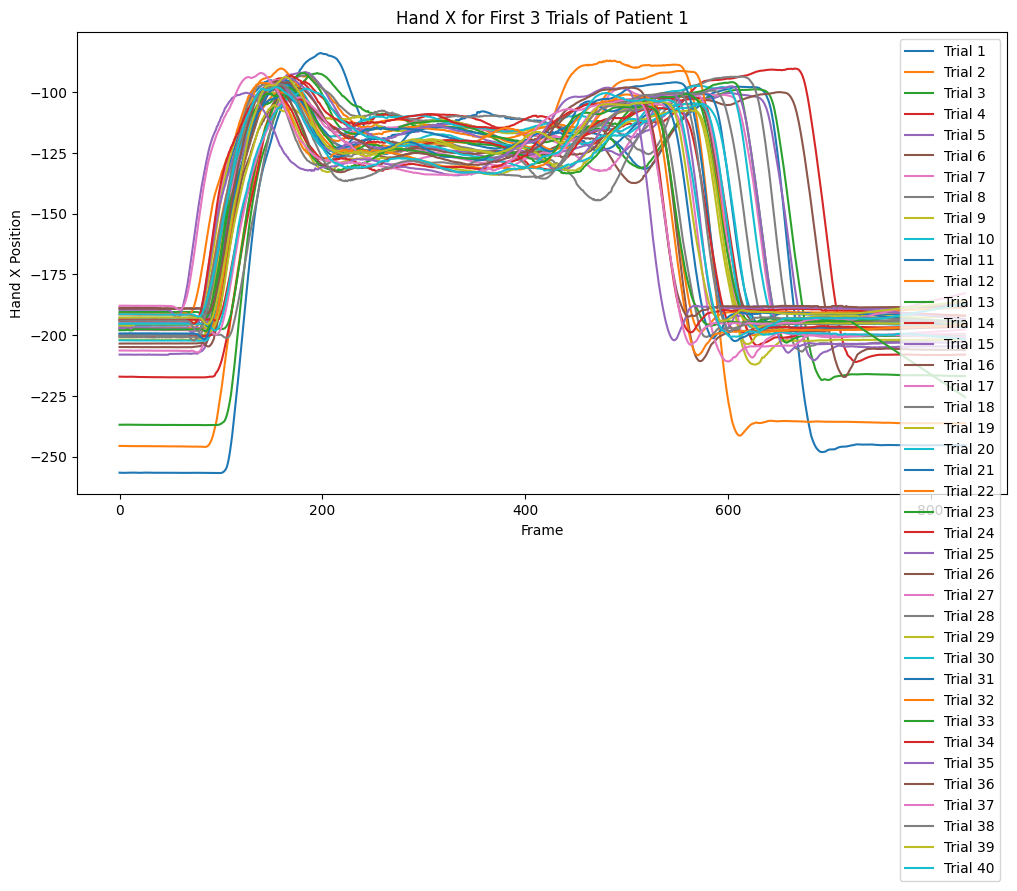

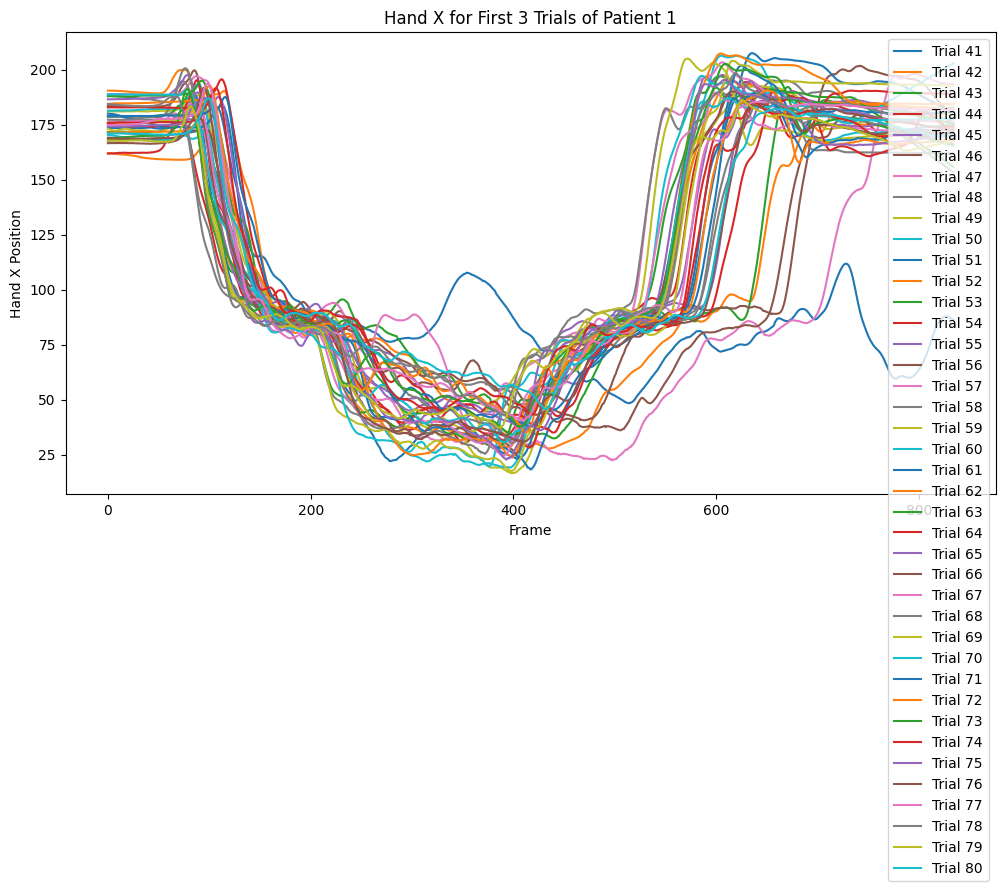

In [21]:
import matplotlib.pyplot as plt

# Select the first patient (index 0)
patient_data = overall_dfs[0]

# Plot hand_x for the first 3 trials
plt.figure(figsize=(12, 6))
for trial in range(len(patient_data)):
    if patient_data[trial].side[0] == 'R':
        data = patient_data[trial]
        plt.plot(data['hand_x'], label=f'Trial {trial + 1}')

plt.title('Hand X for First 3 Trials of Patient 1')
plt.xlabel('Frame')
plt.ylabel('Hand X Position')
plt.legend()
plt.show()




# Plot hand_x for the first 3 trials
plt.figure(figsize=(12, 6))
for trial in range(len(patient_data)):
    if patient_data[trial].side[0] == 'L':
        data = patient_data[trial]
        plt.plot(data['hand_x'], label=f'Trial {trial + 1}')

plt.title('Hand X for First 3 Trials of Patient 1')
plt.xlabel('Frame')
plt.ylabel('Hand X Position')
plt.legend()
plt.show()



### 2nd method - update the DTW function, for 3D alignment.
- We only align the spatial coordinates (hand_x, hand_y, hand_z)
- In order to do this, we shall use multi-dimensional DTW to align these 3 columns together, which will preserve their relative spatial relationships

In [2]:
from fastdtw import fastdtw
from scipy.interpolate import interp1d
import numpy as np
import pandas as pd
from tqdm import tqdm


def align_hand_coordinates(reference, trial):
    aligned_trial = {}
    
    # Create a 3D array for multi-dimensional DTW
    reference_coords = np.array(reference[['hand_x', 'hand_y', 'hand_z']])
    trial_coords = np.array(trial[['hand_x', 'hand_y', 'hand_z']])
    
    # Compute multi-dimensional DTW
    distance, path = fastdtw(reference_coords, trial_coords)
    path = np.array(path)
    
    for i, col in enumerate(['hand_x', 'hand_y', 'hand_z']):
        interp = interp1d(path[:, 1], trial[col].iloc[path[:, 1]], kind='linear', bounds_error=False, fill_value="extrapolate")
        aligned_trial[col] = interp(np.arange(len(reference[col])))
    
    return pd.DataFrame(aligned_trial)



patient_dir = r"C:\Users\shrinidhi.velan\Documents\Data"

# List only directories (folders) in the specified directory
folder_names = [f for f in os.listdir(patient_dir) if os.path.isdir(os.path.join(patient_dir, f))]


overall_dfs = []

for patient in tqdm(folder_names, desc="Processing patients"):
    trials = []
    aligned_trials = []
    if (patient not in ['P24', 'P34'] ):
        name = os.path.join(os.getcwd(), patient)
        combined_data_with_kinematics = pd.read_pickle(os.path.join(name, "combined_data_with_kinematics.pkl"))
        for index, row in combined_data_with_kinematics.iterrows():
            trials.append(row.kinematics)

        trials = [clean_columns(trial_df).drop(columns='side') for trial_df in trials]
        reference_trial = trials[0]
        aligned_trials = [align_hand_coordinates(reference_trial, trial) for trial in trials]


    overall_dfs.append(aligned_trials)
    

with open('3D_alignment.pkl', 'wb') as file:
    pickle.dump(overall_dfs, file)

Processing patients:   0%|          | 0/24 [00:00<?, ?it/s]


NameError: name 'clean_columns' is not defined

# Alignment of time series for each trial for each patient in question

How was this done?
- We start by cleaning the dataframe column : To not distinguish between the right side and the left (affected and unaffected side), we shall get this information from the overall_df dataframe for all patients, this was done to ensure that all variables are upto date and can be used to compare among themselves
- Align_trial function : Perform a DTW alignment, (dtw distance and optimal alignment path for each column)
- Interpolate to match reference length - the computed alignment path maps the trial's data points to the reference's data points. interp1d creates a function to interpolate the trial values along this path. The trial is interpolated to match the length of the reference. 

Thus, this interpolation is done for all patients separately for all trials. Therefore, my_list's first dimension is for all patients (24 to be precise, counting the 24 and 34 - chest marker missing)

### How does DTW work?
1)  Distance matric construction : construct a distance matrix between 2 sequences. Each element of the matrix represents the distance between points in both sequences
2)  Cost matrix and accumulated cost : accumulate the minimum distances from the start of the sequences to the current point. This accumulated cost represents the optimal path's cumulative distance up to that point
3) Optical path finding
4) Warping path


$\rightarrow$ DTW works well  for positional data, as spatial trajectories naturally separate by side. 

$\rightarrow$ DTW doesn't work well on kinematic measures like velocity, jerk,... as this could lead to overfitting or misalignment because the affected and unaffected sides have fundamentally different motor control strategies.

In [2]:
overall_df = pd.read_csv('overall_patients/overall_measures.csv')
alignment_data_3d = pd.read_pickle('3D_alignment.pkl')
overall_dfs = pd.read_pickle('overall_dtw.pkl')

In [3]:
# Alignment of time series for each trial for each patient in question
for i in range(len(alignment_data_3d)):
    for j in range(len(alignment_data_3d[i])):
        alignment_data_3d[i][j]['side'] = overall_dfs[i][j]['side']
        alignment_data_3d[i][j]['condition'] = overall_dfs[i][j]['condition']


In [5]:
import pickle

with open('3D_alignment.pkl', 'wb') as f:
    pickle.dump(alignment_data_3d, f)


In [13]:
pd.read_csv('raw_appended_data.csv')

,participant_id,trial_number,side,condition,validity,hand_velocity,hand_acceleration,trunk_displacement,elbow_angle,pure_shoulder_angle,...,hand_x,hand_y,hand_z,hand_jerk,path_length,movement_smoothness,curvature,sal_velocity,velocity_change,log_movement_smoothness
0,P01,1,R,unaffected,1,0.000000,0.0,0.000000,88.748284,23.118655,...,-256.569763,353.318176,766.768860,0.000000,1664.013002,3.824233e+14,7.693722,-5.188543,0.000000,33.577549
1,P01,1,R,unaffected,1,4.858055,0.0,0.017395,88.777248,23.121897,...,-256.597260,353.286713,766.793640,0.000000,1664.013002,3.824233e+14,35.881929,-5.129252,4.858055,33.577549
2,P01,1,R,unaffected,1,4.087990,0.0,-0.089172,88.778677,23.130273,...,-256.616455,353.312897,766.768799,0.000000,1664.013002,3.824233e+14,6.277808,-6.086953,-0.770065,33.577549
3,P01,1,R,unaffected,1,4.859044,0.0,-0.073059,88.781346,23.134489,...,-256.647675,353.289917,766.798096,150292.661888,1664.013002,3.824233e+14,32.860190,-6.065536,0.771054,33.577549
4,P01,1,R,unaffected,1,3.530062,0.0,-0.147827,88.794022,23.132440,...,-256.648071,353.291107,766.762817,145967.605133,1664.013002,3.824233e+14,168.687360,-7.060422,-1.328982,33.577549
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1712808,P31,80,L,affected,1,5.151062,0.0,8.383392,104.796193,31.599560,...,187.251572,-57.485592,-71.404793,41136.025641,2021.223079,2.473474e+15,3.883546,-7.061896,-0.943642,35.444400
1712809,P31,80,L,affected,1,4.448419,0.0,8.492981,104.807211,31.589276,...,187.284729,-57.470020,-71.379555,32371.511331,2021.223079,2.473474e+15,6.189552,-7.036547,-0.702643,35.444400
1712810,P31,80,L,affected,1,3.368310,0.0,8.574890,104.800960,31.567209,...,187.316772,-57.477951,-71.372856,37971.496582,2021.223079,2.473474e+15,15.061373,-6.048400,-1.080108,35.444400
1712811,P31,80,L,affected,1,1.812141,0.0,8.680176,104.808718,31.544960,...,187.317612,-57.463730,-71.361656,59334.813183,2021.223079,2.473474e+15,7.368140,-6.097446,-1.556169,35.444400


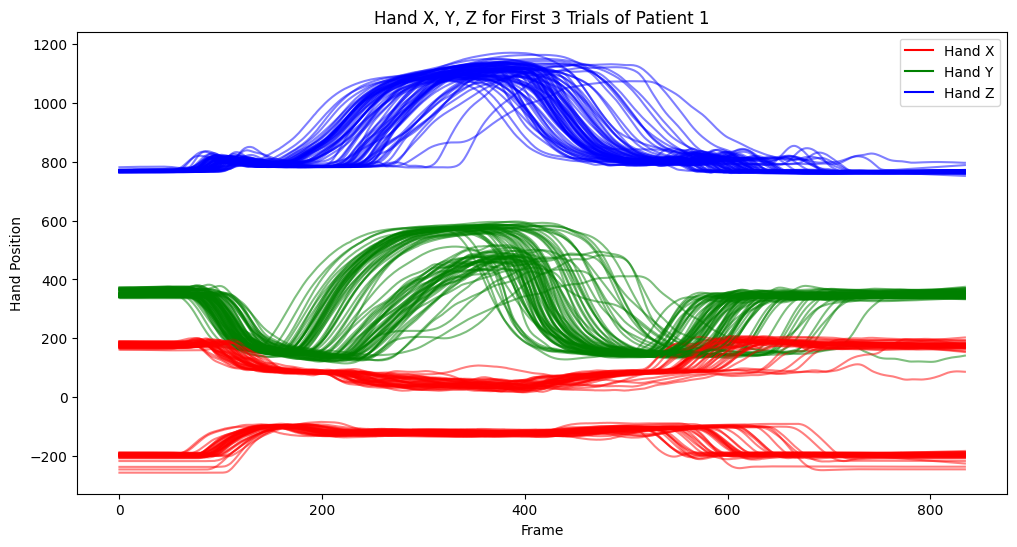

In [55]:
import matplotlib.pyplot as plt

# Select the first patient (index 0)
patient_data = alignment_data_3d[0]

# Define consistent colors for hand_x, hand_y, and hand_z
colors = {'hand_x': 'red', 'hand_y': 'green', 'hand_z': 'blue'}

plt.figure(figsize=(12, 6))

for trial in range(len(patient_data)):
    data = patient_data[trial]
    plt.plot(data['hand_x'], color=colors['hand_x'], alpha=0.5)
    plt.plot(data['hand_y'], color=colors['hand_y'], alpha=0.5)
    plt.plot(data['hand_z'], color=colors['hand_z'], alpha=0.5)

# Create a legend for the hand components
plt.plot([], [], color=colors['hand_x'], label='Hand X')
plt.plot([], [], color=colors['hand_y'], label='Hand Y')
plt.plot([], [], color=colors['hand_z'], label='Hand Z')

plt.title('Hand X, Y, Z for First 3 Trials of Patient 1')
plt.xlabel('Frame')
plt.ylabel('Hand Position')
plt.legend()
plt.show()


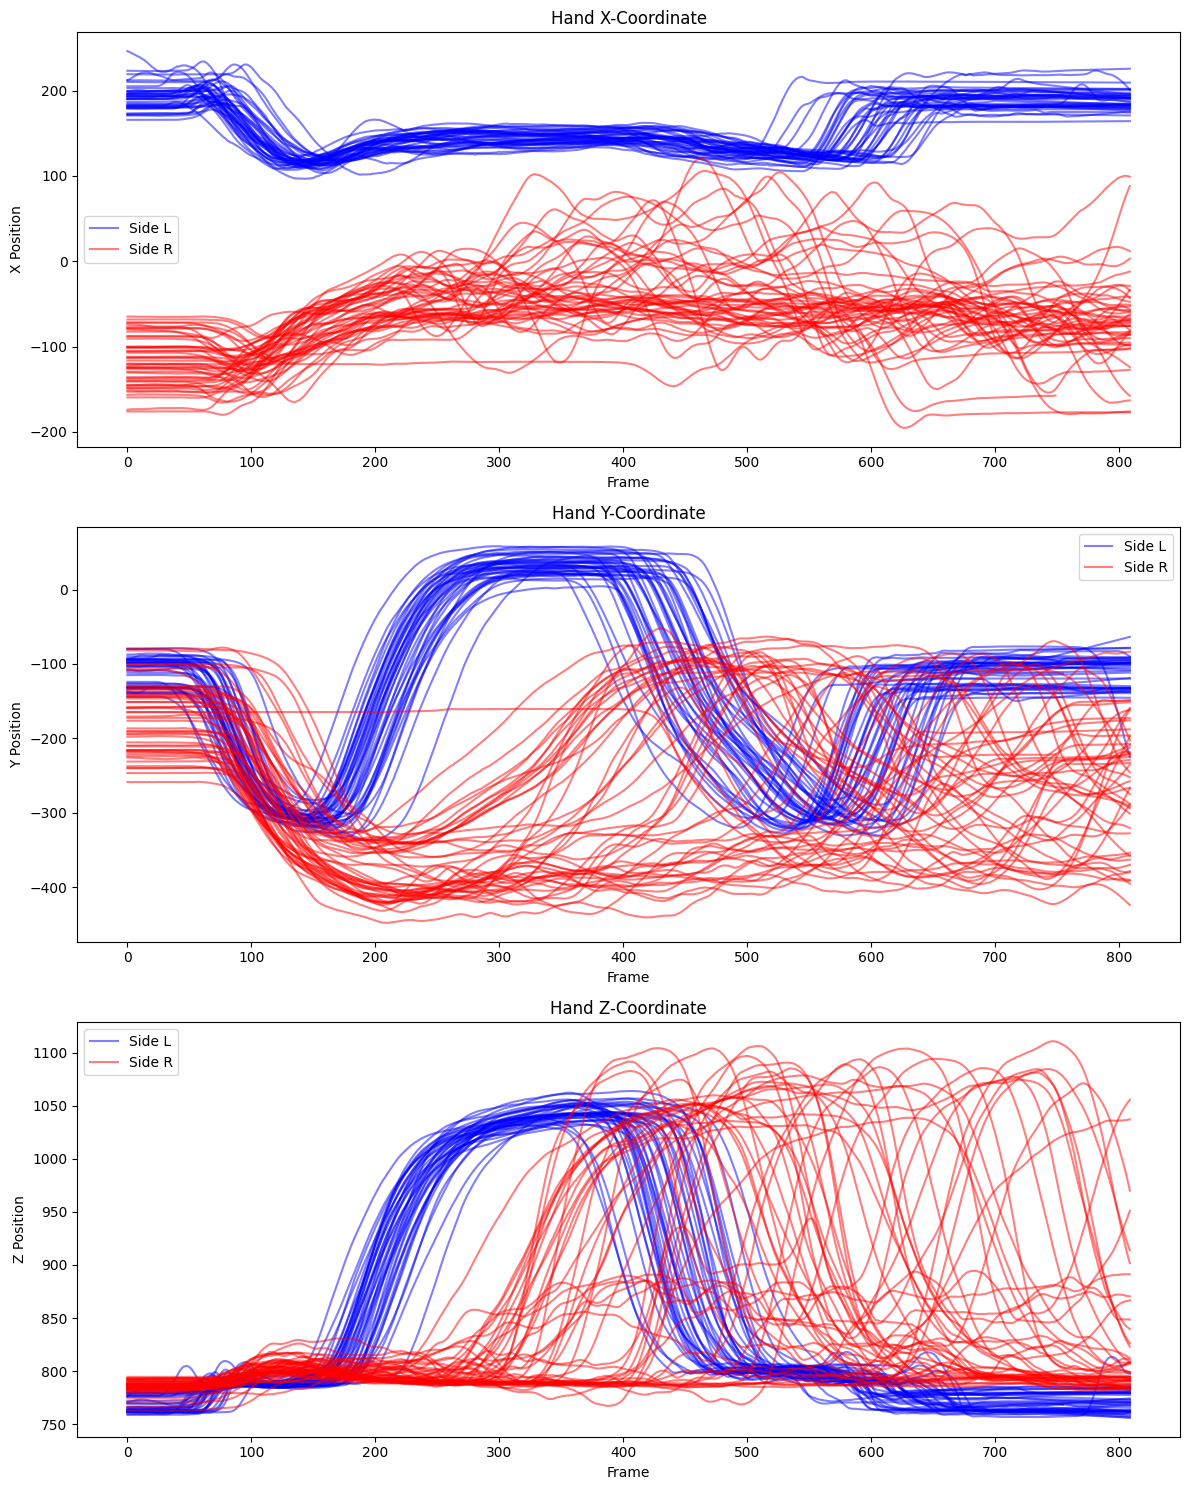


Statistics for hand_x:
Side L:
  Mean: 165.45
  Std: 40.53
Side L:
  Mean: 164.36
  Std: 34.86
Side L:
  Mean: 159.50
  Std: 33.95
Side L:
  Mean: 155.78
  Std: 23.42
Side L:
  Mean: 152.01
  Std: 25.05
Side L:
  Mean: 150.78
  Std: 24.20
Side L:
  Mean: 149.66
  Std: 22.57
Side L:
  Mean: 151.78
  Std: 26.47
Side L:
  Mean: 153.43
  Std: 29.68
Side L:
  Mean: 151.01
  Std: 32.16
Side L:
  Mean: 154.30
  Std: 33.93
Side L:
  Mean: 153.22
  Std: 32.37
Side L:
  Mean: 152.70
  Std: 28.53
Side L:
  Mean: 164.41
  Std: 30.26
Side L:
  Mean: 155.52
  Std: 27.19
Side L:
  Mean: 152.48
  Std: 25.21
Side L:
  Mean: 158.24
  Std: 42.62
Side L:
  Mean: 157.69
  Std: 33.85
Side L:
  Mean: 149.15
  Std: 26.96
Side L:
  Mean: 154.65
  Std: 22.92
Side L:
  Mean: 167.60
  Std: 34.55
Side L:
  Mean: 157.37
  Std: 36.54
Side L:
  Mean: 156.26
  Std: 32.90
Side L:
  Mean: 160.29
  Std: 33.37
Side L:
  Mean: 161.46
  Std: 25.65
Side L:
  Mean: 162.50
  Std: 26.40
Side L:
  Mean: 164.19
  Std: 31.61
Side

In [40]:
import matplotlib.pyplot as plt

# Select the first patient (index 0)
patient_data = alignment_data_3d[2]

# Create figure with 3 subplots, one for each coordinate
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(12, 15))

# Define colors for each side
colors = {'R': 'red', 'L': 'blue'}

# Plot X coordinate
for trial in range(len(patient_data)):
    data = patient_data[trial]
    side = data['side'].iloc[0]  # Get the side for this trial
    ax1.plot(data['hand_x'], color=colors[side], alpha=0.5, label=f'Side {side}')
ax1.set_title('Hand X-Coordinate')
ax1.set_xlabel('Frame')
ax1.set_ylabel('X Position')
# Add legend without duplicates
handles, labels = ax1.get_legend_handles_labels()
by_label = dict(zip(labels, handles))
ax1.legend(by_label.values(), by_label.keys())

# Plot Y coordinate
for trial in range(len(patient_data)):
    data = patient_data[trial]
    side = data['side'].iloc[0]
    ax2.plot(data['hand_y'], color=colors[side], alpha=0.5, label=f'Side {side}')
ax2.set_title('Hand Y-Coordinate')
ax2.set_xlabel('Frame')
ax2.set_ylabel('Y Position')
handles, labels = ax2.get_legend_handles_labels()
by_label = dict(zip(labels, handles))
ax2.legend(by_label.values(), by_label.keys())

# Plot Z coordinate
for trial in range(len(patient_data)):
    data = patient_data[trial]
    side = data['side'].iloc[0]
    ax3.plot(data['hand_z'], color=colors[side], alpha=0.5, label=f'Side {side}')
ax3.set_title('Hand Z-Coordinate')
ax3.set_xlabel('Frame')
ax3.set_ylabel('Z Position')
handles, labels = ax3.get_legend_handles_labels()
by_label = dict(zip(labels, handles))
ax3.legend(by_label.values(), by_label.keys())

# Adjust layout to prevent overlap
plt.tight_layout()
plt.show()

# Optional: Print summary statistics for each coordinate and side
for coordinate in ['hand_x', 'hand_y', 'hand_z']:
    print(f"\nStatistics for {coordinate}:")
    for trial in range(len(patient_data)):
        data = patient_data[trial]
        side = data['side'].iloc[0]
        print(f"Side {side}:")
        print(f"  Mean: {data[coordinate].mean():.2f}")
        print(f"  Std: {data[coordinate].std():.2f}")

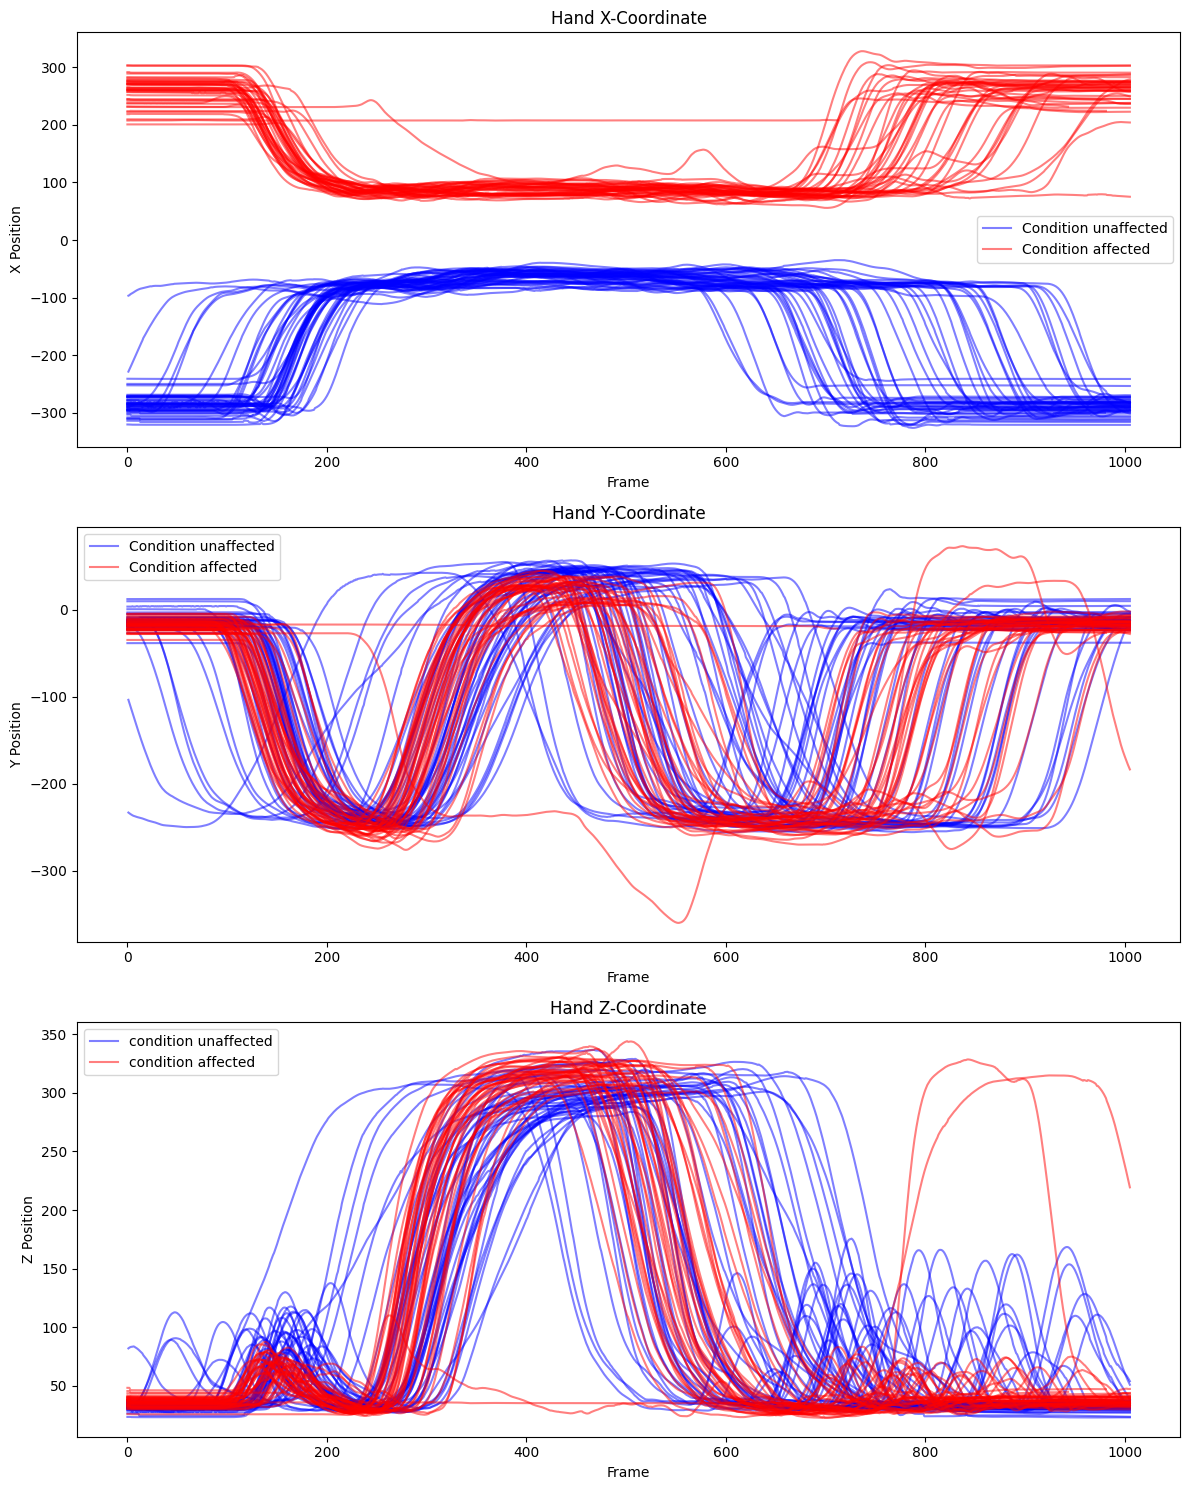


Statistics for hand_x:
Condition unaffected:
  Mean: -160.26
  Std: 77.76
Condition unaffected:
  Mean: -169.01
  Std: 79.34
Condition unaffected:
  Mean: -175.48
  Std: 94.07
Condition unaffected:
  Mean: -174.37
  Std: 94.77
Condition unaffected:
  Mean: -174.97
  Std: 96.94
Condition unaffected:
  Mean: -179.02
  Std: 99.90
Condition unaffected:
  Mean: -163.32
  Std: 103.72
Condition unaffected:
  Mean: -177.38
  Std: 104.18
Condition unaffected:
  Mean: -176.92
  Std: 106.46
Condition unaffected:
  Mean: -169.80
  Std: 100.49
Condition unaffected:
  Mean: -159.33
  Std: 99.01
Condition unaffected:
  Mean: -163.24
  Std: 105.24
Condition unaffected:
  Mean: -170.91
  Std: 112.40
Condition unaffected:
  Mean: -174.23
  Std: 112.31
Condition unaffected:
  Mean: -177.40
  Std: 112.28
Condition unaffected:
  Mean: -170.27
  Std: 108.60
Condition unaffected:
  Mean: -172.86
  Std: 107.83
Condition unaffected:
  Mean: -164.54
  Std: 108.88
Condition unaffected:
  Mean: -158.26
  Std: 10

In [123]:
import matplotlib.pyplot as plt

# Select the first patient (index 0)
patient_data = alignment_data_3d[6]

# Create figure with 3 subplots, one for each coordinate
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(12, 15))

# Define colors for each side
colors = {'affected': 'red', 'unaffected': 'blue'}

for trial in range(len(patient_data)):
    data = patient_data[trial]
    condition = data['condition'].iloc[0] 
    ax1.plot(data['hand_x'], color=colors[condition], alpha=0.5, label=f'Condition {condition}')
ax1.set_title('Hand X-Coordinate')
ax1.set_xlabel('Frame')
ax1.set_ylabel('X Position')
# Add legend without duplicates
handles, labels = ax1.get_legend_handles_labels()
by_label = dict(zip(labels, handles))
ax1.legend(by_label.values(), by_label.keys())

# Plot Y coordinate
for trial in range(len(patient_data)):
    data = patient_data[trial]
    condition = data['condition'].iloc[0]
    ax2.plot(data['hand_y'], color=colors[condition], alpha=0.5, label=f'Condition {condition}')
ax2.set_title('Hand Y-Coordinate')
ax2.set_xlabel('Frame')
ax2.set_ylabel('Y Position')
handles, labels = ax2.get_legend_handles_labels()
by_label = dict(zip(labels, handles))
ax2.legend(by_label.values(), by_label.keys())

# Plot Z coordinate
for trial in range(len(patient_data)):
    data = patient_data[trial]
    condition = data['condition'].iloc[0]
    ax3.plot(data['hand_z'], color=colors[condition], alpha=0.5, label=f'condition {condition}')
ax3.set_title('Hand Z-Coordinate')
ax3.set_xlabel('Frame')
ax3.set_ylabel('Z Position')
handles, labels = ax3.get_legend_handles_labels()
by_label = dict(zip(labels, handles))
ax3.legend(by_label.values(), by_label.keys())

# Adjust layout to prevent overlap
plt.tight_layout()
plt.show()

# Optional: Print summary statistics for each coordinate and side
for coordinate in ['hand_x', 'hand_y', 'hand_z']:
    print(f"\nStatistics for {coordinate}:")
    for trial in range(len(patient_data)):
        data = patient_data[trial]
        condition = data['condition'].iloc[0]
        print(f"Condition {condition}:")
        print(f"  Mean: {data[coordinate].mean():.2f}")
        print(f"  Std: {data[coordinate].std():.2f}")